In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from sklearn.metrics import classification_report, confusion_matrix

import torch.nn as nn
from torchvision.models import (
    mobilenet_v2,
    MobileNet_V2_Weights
)

import matplotlib.pyplot as plt
import seaborn as sns

natural dataset kaggle link " https://www.kaggle.com/datasets/prasunroy/natural-images?resource=download"

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


### Load entire dataset


In [3]:
# Fix — add Normalize
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
dataset = datasets.ImageFolder(
    "skin_vs_nonskin_Validator/train",
    transform=transform
)

print(dataset.classes)
print("Total Images:", len(dataset))

['nonskin', 'skin']
Total Images: 15914


### Train / Validation Split

In [4]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size])

print("Train Images:", len(train_dataset))
print("Validation Images:", len(val_dataset))

Train Images: 12731
Validation Images: 3183


### DataLoader

In [5]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train Batches:", len(train_loader))
print("Validation Batches:", len(val_loader))

Train Batches: 398
Validation Batches: 100


### Device

In [6]:

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


### Mobilenet

In [7]:


model = mobilenet_v2(
    weights=MobileNet_V2_Weights.DEFAULT
)

num_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    num_features,
    2
)

model = model.to(device)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


### Loss function + Optimizer

In [8]:
# Compute weights
skin_count    = 8038
nonskin_count = 4693
total         = skin_count + nonskin_count

weight_nonskin = total / (2 * nonskin_count)  # 1.35
weight_skin    = total / (2 * skin_count)     # 0.82

class_weights = torch.tensor(
    [weight_nonskin, weight_skin],
    dtype=torch.float
).to(device)

# Replace your criterion
criterion = nn.CrossEntropyLoss(weight=class_weights)

In [9]:

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

### training function

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

### val Function

In [11]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

### Training loop

In [12]:
EPOCHS = 10

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

Epoch [1/10] | Train Loss: 0.0402 | Train Acc: 99.20% | Val Loss: 0.0007 | Val Acc: 100.00%
Epoch [2/10] | Train Loss: 0.0018 | Train Acc: 99.98% | Val Loss: 0.0004 | Val Acc: 100.00%
Epoch [3/10] | Train Loss: 0.0005 | Train Acc: 100.00% | Val Loss: 0.0001 | Val Acc: 100.00%
Epoch [4/10] | Train Loss: 0.0009 | Train Acc: 99.99% | Val Loss: 0.0003 | Val Acc: 100.00%
Epoch [5/10] | Train Loss: 0.0002 | Train Acc: 100.00% | Val Loss: 0.0000 | Val Acc: 100.00%
Epoch [6/10] | Train Loss: 0.0001 | Train Acc: 100.00% | Val Loss: 0.0000 | Val Acc: 100.00%
Epoch [7/10] | Train Loss: 0.0008 | Train Acc: 99.98% | Val Loss: 0.0002 | Val Acc: 100.00%
Epoch [8/10] | Train Loss: 0.0005 | Train Acc: 99.98% | Val Loss: 0.0002 | Val Acc: 100.00%
Epoch [9/10] | Train Loss: 0.0003 | Train Acc: 99.99% | Val Loss: 0.0000 | Val Acc: 100.00%
Epoch [10/10] | Train Loss: 0.0001 | Train Acc: 100.00% | Val Loss: 0.0000 | Val Acc: 100.00%


In [18]:
print(dataset.class_to_idx)


{'nonskin': 0, 'skin': 1}


In [19]:
from collections import Counter

train_labels = [
    dataset.samples[i][1]
    for i in train_dataset.indices
]

val_labels = [
    dataset.samples[i][1]
    for i in val_dataset.indices
]

print("Train:", Counter(train_labels))
print("Val:", Counter(val_labels))


Train: Counter({1: 7989, 0: 4742})
Val: Counter({1: 2026, 0: 1157})


In [20]:
train_indices = set(train_dataset.indices)
val_indices = set(val_dataset.indices)

overlap = train_indices.intersection(val_indices)

print("Overlap Images:", len(overlap))

Overlap Images: 0


## "testing

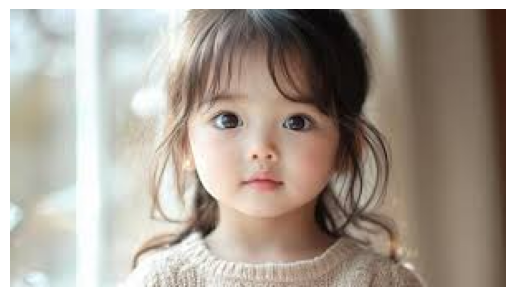

In [31]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = "uploads/kid.jpeg"   # example

image = Image.open(image_path).convert("RGB")

plt.imshow(image)
plt.axis("off")
plt.show()

In [32]:
def predict_skin_validator(image_path, threshold=0.70):
    """
    Returns True if image is a valid skin lesion image.
    threshold: minimum confidence required to classify as skin
    """
    SKIN_IDX = 1   # confirmed from class_to_idx: {'nonskin':0, 'skin':1}

    image        = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor)
        probs   = torch.softmax(outputs, dim=1)[0]

    skin_confidence    = probs[SKIN_IDX].item()
    nonskin_confidence = probs[1 - SKIN_IDX].item()
    is_skin            = skin_confidence >= threshold

    print(f"Skin confidence    : {skin_confidence*100:.2f}%")
    print(f"Non-skin confidence: {nonskin_confidence*100:.2f}%")
    print(f"Decision           : {'✅ SKIN — forwarding to fusion model' if is_skin else '❌ REJECTED — not a skin lesion image'}")

    return is_skin, skin_confidence

In [33]:
predict_skin_validator(image_path)

Skin confidence    : 0.33%
Non-skin confidence: 99.67%
Decision           : ❌ REJECTED — not a skin lesion image


(False, 0.0033392994664609432)

In [34]:

# ── Define save path ──
save_dir  = "skin_vs_nonskin_Validator"
save_path = os.path.join(save_dir, "skin_validator_best.pth")

# ── Save model ──
torch.save(model.state_dict(), save_path)
print(f"✔ Validator model saved to: {save_path}")

# ── Verify file exists ──
if os.path.exists(save_path):
    size_mb = os.path.getsize(save_path) / (1024 * 1024)
    print(f"✔ File confirmed: {save_path} ({size_mb:.2f} MB)")
else:
    print("❌ Save failed — file not found")

✔ Validator model saved to: skin_vs_nonskin_Validator/skin_validator_best.pth
✔ File confirmed: skin_vs_nonskin_Validator/skin_validator_best.pth (8.73 MB)
